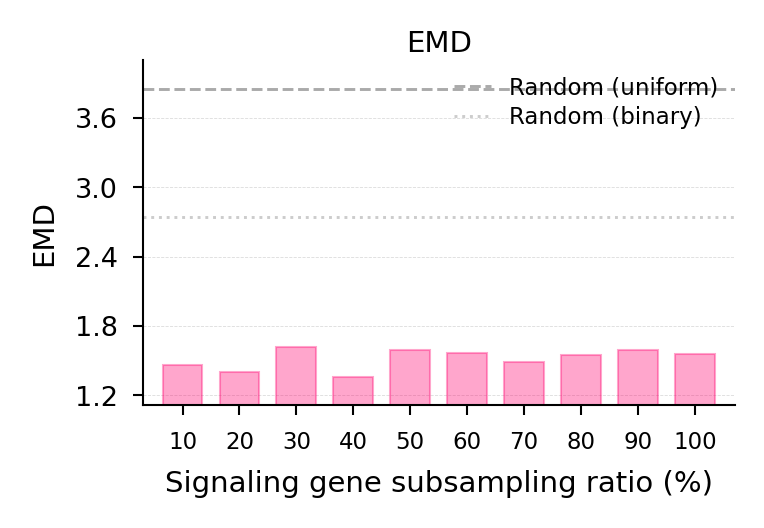

Saved gene_panel_robustness_emd.pdf / .svg / .png


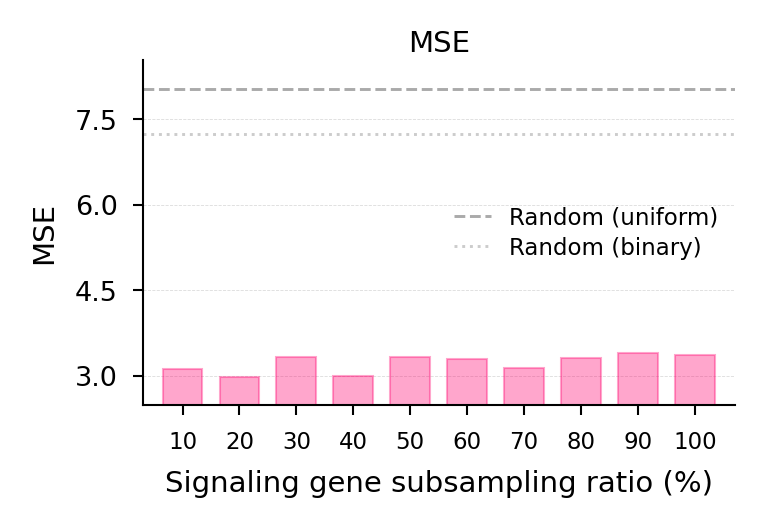

Saved gene_panel_robustness_mse.pdf / .svg / .png


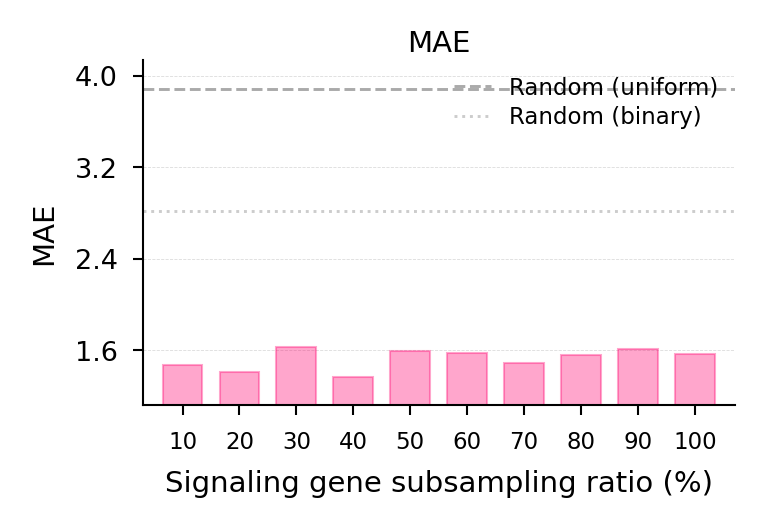

Saved gene_panel_robustness_mae.pdf / .svg / .png


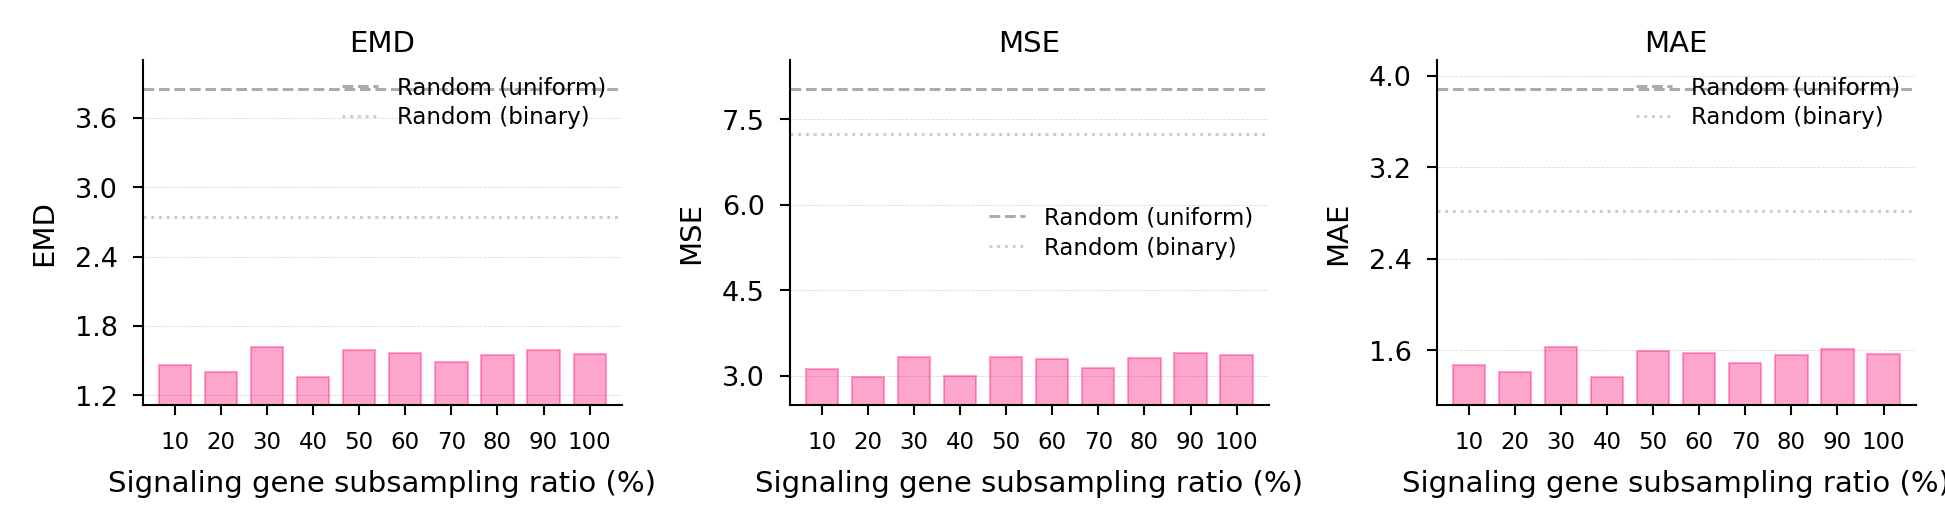


Saved gene_panel_robustness_combined.pdf / .svg / .png


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Paths ───────────────────────────────────────────────────────────────
DATA_PATH = (
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/"
    "AK_Private/19_Synthetic_PanelRobustness_Option1/NonGit/DFs_for_Figures/"
    "gene_panel_robustness_for_Seb.pkl"
)

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/gene_panel_robustness"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Colours ────────────────────────────────────────────────────────────
method_colors = {
    "MintFlow": "#FF006E",
    "Random (uniform)": "#AAAAAA",
    "Random (binary)": "#CCCCCC",
}

method_rename = {
    "mintflow": "MintFlow",
    "inflow": "MintFlow",
    "random_uniform": "Random (uniform)",
    "random": "Random (uniform)",
    "random_binary": "Random (binary)",
}

# ── Load data ───────────────────────────────────────────────────────────
df = pd.read_pickle(DATA_PATH)

# Standardise names
df = df.copy()
df["method"] = df["method"].replace(method_rename)

# Use the signalling-gene ratio column
ratio_col = "percentage_included_signalling_genes"
if ratio_col not in df.columns:
    # Fallback for older naming
    ratio_col = "percentage_subsample"

required = {"metric", "value", "method", ratio_col}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only methods needed for this figure
df = df[df["method"].isin(["MintFlow", "Random (uniform)", "Random (binary)"])]

# Ensure numeric sorting
df[ratio_col] = pd.to_numeric(df[ratio_col])
df["value"] = pd.to_numeric(df["value"])

metric_names = ["EMD", "MSE", "MAE"]
metric_names = [m for m in metric_names if m in df["metric"].unique()]


# ── Helper: plot one metric ─────────────────────────────────────────────
def plot_metric(ax, df_metric, metric_name):
    """Plot MintFlow bars across signalling-gene subsampling ratios,
    with random baselines shown as horizontal lines using 100% values only.
    """

    mint = df_metric[df_metric["method"] == "MintFlow"].copy()

    if mint.empty:
        raise ValueError(f"No MintFlow values found for metric {metric_name}")

    summary = (
        mint
        .groupby(ratio_col, as_index=False)
        .agg(
            mean=("value", "mean"),
            sem=("value", "sem"),
            n=("value", "size"),
        )
        .sort_values(ratio_col)
    )

    summary["sem"] = summary["sem"].fillna(0)

    x = summary[ratio_col].to_numpy()
    y = summary["mean"].to_numpy()
    yerr = summary["sem"].to_numpy()

    # Estimate bar width from spacing
    if len(x) > 1:
        bar_width = np.min(np.diff(np.sort(x))) * 0.7
    else:
        bar_width = 6

    # MintFlow bars
    ax.bar(
        x,
        y,
        width=bar_width,
        color=method_colors["MintFlow"],
        edgecolor=method_colors["MintFlow"],
        linewidth=0.5,
        alpha=0.35,
        zorder=2,
    )

    # Only draw error bars if there is more than one replicate anywhere
    if (summary["n"] > 1).any():
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor="0.3",
            elinewidth=0.5,
            capsize=1.4,
            capthick=0.5,
            zorder=3,
        )

    # Random baselines: only use 100% signalling-gene ratio
    baseline_styles = {
        "Random (uniform)": {
            "color": method_colors["Random (uniform)"],
            "linestyle": "--",
        },
        "Random (binary)": {
            "color": method_colors["Random (binary)"],
            "linestyle": ":",
        },
    }

    baseline_values = []

    for baseline_method, style in baseline_styles.items():
        baseline_df = df_metric[
            (df_metric["method"] == baseline_method)
            & (df_metric[ratio_col] == 100)
        ]

        if baseline_df.empty:
            print(
                f"Warning: no 100% baseline found for "
                f"{baseline_method} / {metric_name}"
            )
            continue

        baseline_value = baseline_df["value"].mean()
        baseline_values.append(baseline_value)

        ax.axhline(
            baseline_value,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=0.7,
            zorder=1,
            label=baseline_method,
        )

    # Axes styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.yaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    ax.set_xlabel("Signaling gene subsampling ratio (%)", fontweight="medium")
    ax.set_ylabel(f"{metric_name}", fontweight="medium")
    ax.set_title(metric_name, fontweight="medium", pad=2)

    ax.set_xticks(x)
    ax.set_xlim(x.min() - bar_width, x.max() + bar_width)

    # Sensible y limits including baselines
    all_y = list(y)
    if (summary["n"] > 1).any():
        all_y.extend(y - yerr)
        all_y.extend(y + yerr)
    all_y.extend(baseline_values)

    y_min = np.nanmin(all_y)
    y_max = np.nanmax(all_y)
    y_pad = (y_max - y_min) * 0.10 if y_max > y_min else 0.1

    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=False))

    ax.legend(
        frameon=False,
        fontsize=5.5,
        handlelength=1.6,
        borderpad=0.2,
        labelspacing=0.3,
        loc="best",
    )


# ── Save one plot per metric ────────────────────────────────────────────
single_panel_width = 65 * mm
single_panel_height = 45 * mm

for metric_name in metric_names:
    df_metric = df[df["metric"] == metric_name]

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(single_panel_width, single_panel_height),
    )

    plot_metric(ax, df_metric, metric_name)

    plt.tight_layout()

    for ext in ["pdf", "svg", "png"]:
        out_path = os.path.join(
            OUT_DIR,
            f"gene_panel_robustness_{metric_name.lower()}.{ext}",
        )
        fig.savefig(out_path, bbox_inches="tight", pad_inches=0.05)

    plt.show()
    plt.close(fig)

    print(f"Saved gene_panel_robustness_{metric_name.lower()}.pdf / .svg / .png")


# ── Optional: combined 1×3 figure ───────────────────────────────────────
panel_width = 55 * mm
fig_height = 45 * mm
fig_width = panel_width * len(metric_names)

fig, axes = plt.subplots(
    1,
    len(metric_names),
    figsize=(fig_width, fig_height),
    squeeze=False,
)

axes = axes[0]

for ax, metric_name in zip(axes, metric_names):
    df_metric = df[df["metric"] == metric_name]
    plot_metric(ax, df_metric, metric_name)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)

for ext in ["pdf", "svg", "png"]:
    out_path = os.path.join(
        OUT_DIR,
        f"gene_panel_robustness_combined.{ext}",
    )
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0.05)

plt.show()
plt.close(fig)

print("\nSaved gene_panel_robustness_combined.pdf / .svg / .png")